<a href="https://colab.research.google.com/github/SyedSameena18/CodeAlpha_SentimentAnalysis/blob/main/CODEALPHA_TASK4_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***AIRLINE PASSENGER REVIEW SENTIMENT ANALYSIS USING MACHINE LEARNING***
## Project Objective

The objective of this project is to analyze airline passenger reviews using Natural Language Processing (NLP) and Machine Learning techniques. The model classifies customer reviews into positive and negative sentiments, helping airlines understand customer satisfaction and improve service quality.



IMPORTNG LIBRARIES -

In [117]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing
import re
import nltk

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Word Cloud
from wordcloud import WordCloud

# required NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


LOADING DATASET -

In [118]:
df = pd.read_csv('/content/Airline_review.csv.zip')

DATASET OVERVIEW -

In [119]:
df.shape

(23171, 20)

In [120]:
df.head()

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  object 
 2   Overall_Rating          23171 non-null  object 
 3   Review_Title            23171 non-null  object 
 4   Review Date             23171 non-null  object 
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  object 
 7   Aircraft                7129 non-null   object 
 8   Type Of Traveller       19433 non-null  object 
 9   Seat Type               22075 non-null  object 
 10  Route                   19343 non-null  object 
 11  Date Flown              19417 non-null  object 
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null

In [122]:
df.columns.tolist()

['Unnamed: 0',
 'Airline Name',
 'Overall_Rating',
 'Review_Title',
 'Review Date',
 'Verified',
 'Review',
 'Aircraft',
 'Type Of Traveller',
 'Seat Type',
 'Route',
 'Date Flown',
 'Seat Comfort',
 'Cabin Staff Service',
 'Food & Beverages',
 'Ground Service',
 'Inflight Entertainment',
 'Wifi & Connectivity',
 'Value For Money',
 'Recommended']

DATA CLEANING -


In [123]:
#missing values
df.isnull().sum()

,0
Unnamed: 0,0
Airline Name,0
Overall_Rating,0
Review_Title,0
Review Date,0
Verified,0
Review,0
Aircraft,16042
Type Of Traveller,3738
Seat Type,1096


In [124]:
#duplicates
df.duplicated().sum()

np.int64(0)

In [125]:
df = df[['Review', 'Recommended']]
df.head()

,Review,Recommended
0,Moroni to Moheli. Turned out to be a pretty ...,yes
1,Moroni to Anjouan. It is a very small airline...,no
2,Anjouan to Dzaoudzi. A very small airline an...,no
3,Please do a favor yourself and do not fly wi...,no
4,Do not book a flight with this airline! My fr...,no


TARGET LABELS-

In [126]:
df['Recommended'] = df['Recommended'].map({
    'yes': 1,
    'no': 0
})
df.head()

,Review,Recommended
0,Moroni to Moheli. Turned out to be a pretty ...,1
1,Moroni to Anjouan. It is a very small airline...,0
2,Anjouan to Dzaoudzi. A very small airline an...,0
3,Please do a favor yourself and do not fly wi...,0
4,Do not book a flight with this airline! My fr...,0


CLASS DISTRIBUTION-

In [127]:
df['Recommended'].value_counts()

,count
Recommended,
0,15364
1,7807


In [128]:
df['Recommended'].value_counts()

,count
Recommended,
0,15364
1,7807


We need Review (text) and Recommended (label) to build the sentiment classifier.

Mapping:

yes → 1 (Positive)

no → 0 (Negative)

# ***NLP TEXT PROCESSING-***

In [129]:
# Text Cleaning Function

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    words = nltk.word_tokenize(text)

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [130]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [131]:
df['Clean_Review'] = df['Review'].apply(clean_text)

In [132]:
df[['Review', 'Clean_Review']].head()

,Review,Clean_Review
0,Moroni to Moheli. Turned out to be a pretty ...,moroni moheli turned pretty decent airline onl...
1,Moroni to Anjouan. It is a very small airline...,moroni anjouan small airline ticket advised tu...
2,Anjouan to Dzaoudzi. A very small airline an...,anjouan dzaoudzi small airline airline based c...
3,Please do a favor yourself and do not fly wi...,please favor fly adria route munich pristina j...
4,Do not book a flight with this airline! My fr...,book flight airline friend returned sofia amst...


In [133]:
(df['Clean_Review'].str.len() == 0).sum()

np.int64(0)

TF-IDF FEATURE EXTRACTION -

In [134]:
#Features (X) and Target (y)
X = df['Clean_Review']
y = df['Recommended']

In [135]:
#Convert Text to TF-IDF Features
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X)

In [136]:
#Feature Matrix Shape
print(X.shape)

(23171, 5000)


TRAIN-TEST SPLIT

In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [138]:
#Verify the Split
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (18536, 5000)
Testing Data  : (4635, 5000)


In [139]:
X.shape


(23171, 5000)

In [140]:
X_train.shape


(18536, 5000)

In [141]:
X_test.shape

(4635, 5000)

TF-IDF converts words into numerical features while giving more importance to informative words.

Train-test split keeps 80% of the data for training and 20% for testing.

stratify=y preserves the original class distribution (about 66% negative and 34% positive) in both sets, which is important because your dataset is imbalanced.

# ***MODEL TRAINING - LOGISTIC REGRESSION MODEL***

We chose Logistic Regression because:

It is specifically designed for binary classification problems.
Our target variable (Recommended) has only two classes:

1 → Recommended (Positive)

0 → Not Recommended (Negative)

Since the goal is to predict one of two possible outcomes, Logistic Regression is a natural choice.

In [142]:
# Train Logistic Regression Model

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [143]:
# predictions
y_pred = model.predict(X_test)

MODEL EVALUATION -

In [144]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8985976267529665


In [145]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      3073
           1       0.87      0.83      0.85      1562

    accuracy                           0.90      4635
   macro avg       0.89      0.88      0.89      4635
weighted avg       0.90      0.90      0.90      4635



[[2873  200]
 [ 270 1292]]


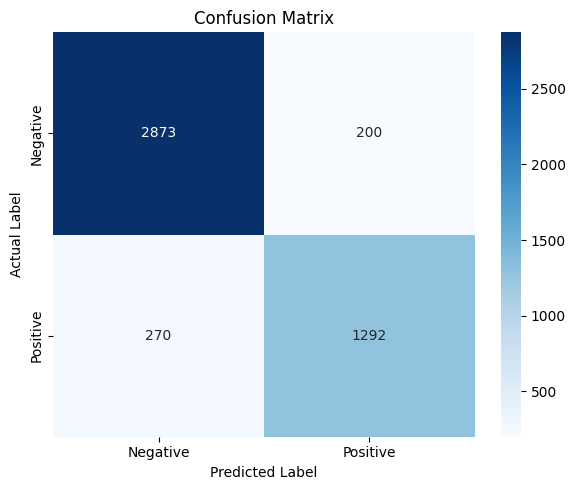

In [146]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

#VISUALIZATION
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

plt.show()


The confusion matrix demonstrates the performance of the Logistic Regression model in classifying airline passenger reviews.

- 2873 negative reviews were correctly classified as negative.
- 1292 positive reviews were correctly classified as positive.
- 200 negative reviews were incorrectly classified as positive.
- 270 positive reviews were incorrectly classified as negative.

The model achieved an overall accuracy of approximately **89.86%**, indicating strong predictive performance for airline review sentiment classification.

# ***MODEL PERFORMANCE-***


- Logistic Regression was used as the classification model.
- The confusion matrix illustrates the number of correctly and incorrectly classified reviews.
- Accuracy measures the overall performance of the model on unseen data.

True Negatives (TN) = 2873
These reviews were actually negative, and the model correctly predicted them as negative.

False Positives (FP) = 200
These reviews were actually negative, but the model incorrectly predicted them as positive.

False Negatives (FN) = 270
These reviews were actually positive, but the model incorrectly predicted them as negative.

True Positives (TP) = 1292
These reviews were actually positive, and the model correctly predicted them as positive.

# ***EVALUATION METRICS -***

Accuracy: 89.86%

Precision (Positive class): 0.87

Recall (Positive class): 0.83

F1-score (Positive class): 0.85

# ***VISUALIZATION-***

/tmp/ipykernel_8785/173649057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


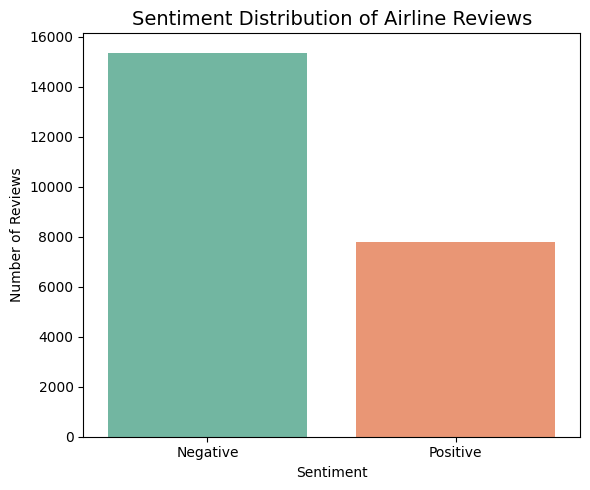

In [147]:
#1.Sentiment Distribution:
plt.figure(figsize=(6,5))
sns.countplot(
    x='Recommended',
    data=df,
    palette='Set2'
)

plt.title("Sentiment Distribution of Airline Reviews", fontsize=14)
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(
    ticks=[0,1],
    labels=['Negative','Positive']
)
plt.tight_layout()

plt.show()


- The chart displays the distribution of positive and negative airline reviews.
- Negative reviews are more frequent than positive reviews.
- This indicates that the dataset is imbalanced, with a higher proportion of dissatisfied passengers.

In [148]:
#2.Custom Review Prediction:
def predict_sentiment(review):
    # Clean the review
    cleaned_review = clean_text(review)
    # Convert to TF-IDF
    vector = tfidf.transform([cleaned_review])
    # Predict
    prediction = model.predict(vector)[0]
    if prediction == 1:
        return "😊 Positive Review (Recommended)"
    else:
        return "😞 Negative Review (Not Recommended)"

In [149]:
#test1
review = "The flight was excellent. The cabin crew was friendly and the seats were comfortable."
print(predict_sentiment(review))

😊 Positive Review (Recommended)


In [150]:
#test2
review = "Worst airline ever. Flight was delayed for six hours and customer service was terrible."
print(predict_sentiment(review))

😞 Negative Review (Not Recommended)


In [151]:
#test3
review = "The food was average but the staff were helpful and the flight was comfortable."
print(predict_sentiment(review))

😊 Positive Review (Recommended)



The trained Logistic Regression model successfully predicts the sentiment of new airline reviews.

By preprocessing the input text, converting it into TF-IDF features, and using the trained classifier, the model determines whether a review is :

positive (recommended) or negative (not recommended).

Text(0.5, 1.0, 'Most Frequent Words in Positive Reviews')

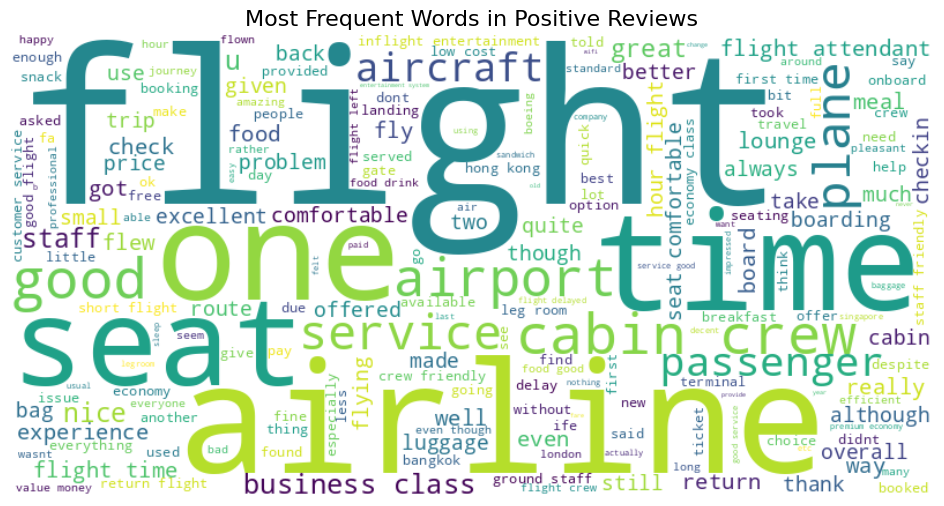

In [152]:
#3.Positive Reviews Word Cloud:
positive_reviews = " ".join(
    df[df['Recommended'] == 1]['Clean_Review']
)
# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)
# Display
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Positive Reviews", fontsize=16)



- The word cloud highlights the most frequently occurring words in positive airline reviews.
- Larger words represent terms that appear more often.
- It provides a quick visual summary of the aspects customers appreciate most.

Text(0.5, 1.0, 'Most Frequent Words in Negative Reviews')

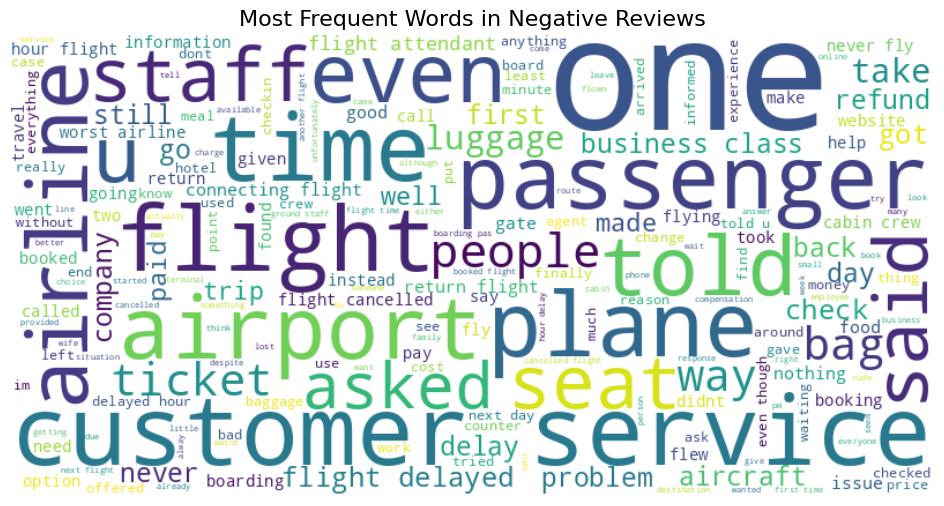

In [153]:
#4.Negative Reviews Word Cloud:
negative_reviews = " ".join(
    df[df['Recommended'] == 0]['Clean_Review']
)
# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)
# Display
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Negative Reviews", fontsize=16)



- The word cloud highlights the most frequently occurring words in negative airline reviews.
- Larger words represent the issues mentioned most often by passengers.
- It helps identify common customer complaints and areas where airlines may need improvement.